# 1.1 analize structure of data

In [19]:
import kagglehub
import pandas as pd

download = kagglehub.dataset_download("surendhan/titanic-dataset")

path=r'C:\Users\USER098\.cache\kagglehub\datasets\surendhan\titanic-dataset\versions\1\titanic.csv'

df = pd.read_csv(path)

print(df.shape)
print(df.head())

(418, 12)
   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB


In [11]:
df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,418.000000,418.000000,418.000000,418,418,332.000000,418.000000,418.000000,418,417.000000,91,418
unique,NaN,NaN,NaN,418,2,NaN,NaN,NaN,363,NaN,76,3
top,NaN,NaN,NaN,"Kelly, Mr. James",male,NaN,NaN,NaN,PC 17608,NaN,B57 B59 B63 B66,S
freq,NaN,NaN,NaN,1,266,NaN,NaN,NaN,5,NaN,3,270
mean,1100.500000,0.363636,2.265550,NaN,NaN,30.272590,0.447368,0.392344,NaN,35.627188,NaN,NaN
std,120.810458,0.481622,0.841838,NaN,NaN,14.181209,0.896760,0.981429,NaN,55.907576,NaN,NaN
min,892.000000,0.000000,1.000000,NaN,NaN,0.170000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,996.250000,0.000000,1.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN
50%,1100.500000,0.000000,3.000000,NaN,NaN,27.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,1204.750000,1.000000,3.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.500000,NaN,NaN


In [16]:
# SibSp liczba rodzeństwa (siblings) małżonków (spouses)
# Parch liczba rodziców (parents) dzieci (children)
#Fare Cena biletu
df[['Survived','Pclass','Age','SibSp','Parch','Fare']].corr()

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.108615,-0.000013,0.099943,0.159120,0.191514
Pclass,-0.108615,1.000000,-0.492143,0.001087,0.018721,-0.577147
Age,-0.000013,-0.492143,1.000000,-0.091587,-0.061249,0.337932
SibSp,0.099943,0.001087,-0.091587,1.000000,0.306895,0.171539
Parch,0.159120,0.018721,-0.061249,0.306895,1.000000,0.230046
Fare,0.191514,-0.577147,0.337932,0.171539,0.230046,1.000000


# 1.2 analize missing

In [2]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

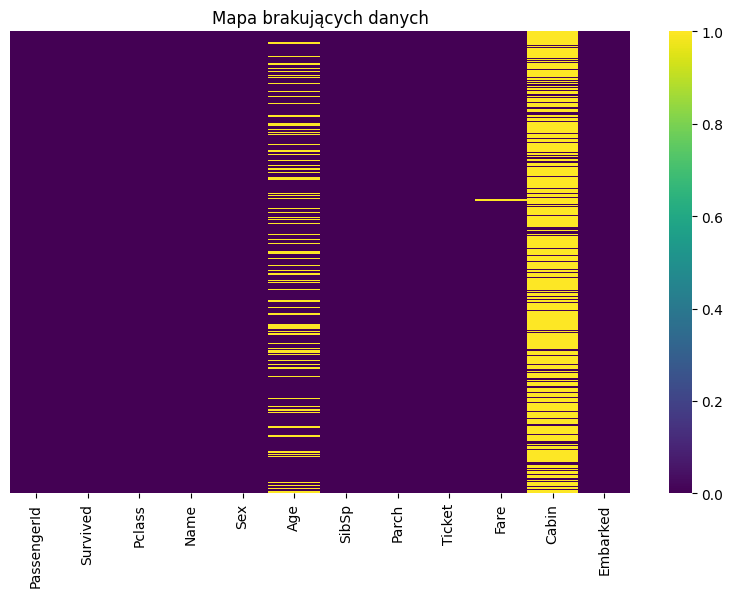

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title("Mapa brakujących danych przed")
plt.show()

In [12]:
import pandas as pd
import numpy as np
import random

def psuj_dataset(df: pd.DataFrame) -> pd.DataFrame:
    seed = 42
    np.random.seed(seed)
    random.seed(seed)

    df_zepsuty = df.copy()

    # 1. BRAKUJĄCE DANE - różne wzorce
    numeric_cols = df_zepsuty.select_dtypes(include=[np.number]).columns.tolist()
    df_zepsuty[numeric_cols] = df_zepsuty[numeric_cols].astype(float)
    categorical_cols = df_zepsuty.select_dtypes(include=['object', 'category']).columns.tolist()

    if len(numeric_cols) > 0:
        # MCAR - losowe braki w kolumnie numerycznej
        col_mcar = random.choice(numeric_cols)
        mask_mcar = np.random.random(len(df_zepsuty)) < 0.15
        df_zepsuty.loc[mask_mcar, col_mcar] = np.nan

        # MAR - braki zależne od innej zmiennej
        if len(numeric_cols) > 1:
            col_mar = random.choice([c for c in numeric_cols if c != col_mcar])
            threshold = df_zepsuty[col_mcar].quantile(0.7) if not df_zepsuty[col_mcar].isna().all() else 0
            mask_mar = (df_zepsuty[col_mcar] > threshold) & (np.random.random(len(df_zepsuty)) < 0.25)
            df_zepsuty.loc[mask_mar, col_mar] = np.nan

        # Kolumna z >60% braków do usunięcia
        if len(numeric_cols) > 2:
            col_duzo_brakow = random.choice([c for c in numeric_cols if c not in [col_mcar, col_mar] if 'col_mar' in locals()])
            mask_duzo = np.random.random(len(df_zepsuty)) < 0.65
            df_zepsuty.loc[mask_duzo, col_duzo_brakow] = np.nan

    if len(categorical_cols) > 0:
        # MNAR - braki w kategorycznej
        col_mnar = random.choice(categorical_cols)
        unique_vals = df_zepsuty[col_mnar].dropna().unique()
        if len(unique_vals) > 1:
            # Braki głównie w jednej kategorii
            target_val = random.choice(unique_vals)
            mask_mnar = (df_zepsuty[col_mnar] == target_val) & (np.random.random(len(df_zepsuty)) < 0.30)
            df_zepsuty.loc[mask_mnar, col_mnar] = np.nan

    # 2. DUPLIKATY
    n_duplicates = int(len(df_zepsuty) * 0.08)  # 8% duplikatów
    if n_duplicates > 0:
        duplicate_indices = np.random.choice(df_zepsuty.index, size=n_duplicates, replace=True)
        df_duplicates = df_zepsuty.loc[duplicate_indices].copy()
        df_zepsuty = pd.concat([df_zepsuty, df_duplicates], ignore_index=True)

    # 3. OUTLIERY
    if len(numeric_cols) > 0:
        for i, col in enumerate(numeric_cols[:min(3, len(numeric_cols))]):
            if df_zepsuty[col].notna().sum() > 0:
                # Różne typy outlierów
                n_outliers = int(len(df_zepsuty) * 0.03)
                outlier_indices = np.random.choice(df_zepsuty.index, size=n_outliers, replace=False)

                mean_val = df_zepsuty[col].mean()
                std_val = df_zepsuty[col].std()

                if i % 3 == 0:
                    # Ekstremalne wartości górne
                    df_zepsuty.loc[outlier_indices, col] = mean_val + (4 + np.random.random(n_outliers) * 3) * std_val
                elif i % 3 == 1:
                    # Ekstremalne wartości dolne
                    df_zepsuty.loc[outlier_indices, col] = mean_val - (4 + np.random.random(n_outliers) * 3) * std_val
                else:
                    # Mix górne i dolne
                    half = n_outliers // 2
                    df_zepsuty.loc[outlier_indices[:half], col] = mean_val + (4 + np.random.random(half) * 2) * std_val
                    df_zepsuty.loc[outlier_indices[half:], col] = mean_val - (4 + np.random.random(n_outliers-half) * 2) * std_val

    # 4. NIESPÓJNOŚCI W DANYCH
    if len(categorical_cols) > 0:
        col_niespojnosc = random.choice(categorical_cols)
        unique_vals = df_zepsuty[col_niespojnosc].dropna().unique()

        if len(unique_vals) > 0:
            # Różne warianty tej samej wartości (whitespace, case)
            n_niespojnosci = int(len(df_zepsuty) * 0.05)
            niespojnosc_indices = np.random.choice(df_zepsuty[df_zepsuty[col_niespojnosc].notna()].index,
                                                   size=min(n_niespojnosci, df_zepsuty[col_niespojnosc].notna().sum()),
                                                   replace=False)

            for idx in niespojnosc_indices:
                val = str(df_zepsuty.loc[idx, col_niespojnosc])
                # Losowy wybór problemu
                problem = random.choice(['lowercase', 'uppercase', 'whitespace', 'typo'])

                if problem == 'lowercase':
                    df_zepsuty.loc[idx, col_niespojnosc] = val.lower()
                elif problem == 'uppercase':
                    df_zepsuty.loc[idx, col_niespojnosc] = val.upper()
                elif problem == 'whitespace':
                    df_zepsuty.loc[idx, col_niespojnosc] = f"  {val}  "
                elif problem == 'typo' and len(val) > 2:
                    # Zamień losową literę
                    pos = random.randint(0, len(val)-1)
                    val_list = list(val)
                    val_list[pos] = random.choice('abcdefghijklmnopqrstuvwxyz')
                    df_zepsuty.loc[idx, col_niespojnosc] = ''.join(val_list)

    # 5. WARTOŚCI POZA SENSOWNYM ZAKRESEM
    if len(numeric_cols) > 0:
        col_nonsense = random.choice([c for c in numeric_cols if c != col_mcar])
        nonsense_indices = np.random.choice(df_zepsuty.index, size=int(len(df_zepsuty) * 0.02), replace=False)

        # Np. ujemne wartości gdzie powinny być dodatnie
        if df_zepsuty[col_nonsense].min() >= 0:
            df_zepsuty.loc[nonsense_indices, col_nonsense] = -abs(df_zepsuty.loc[nonsense_indices, col_nonsense])
        else:
            # Lub bardzo nietypowe wartości
            df_zepsuty.loc[nonsense_indices, col_nonsense] = df_zepsuty[col_nonsense].max() * 100

    # 6. PROBLEMY Z MULTIKOLINEARNOŚCIĄ - stwórz skorelowane kolumny
    if len(numeric_cols) >= 2:
        base_col = random.choice(numeric_cols)
        new_col_name = f"{base_col}_correlated"

        # Stwórz kolumnę silnie skorelowaną (r > 0.9)
        noise = np.random.normal(0, df_zepsuty[base_col].std() * 0.1, len(df_zepsuty))
        df_zepsuty[new_col_name] = df_zepsuty[base_col] * 1.5 + noise + 10

    # Wymieszaj kolejność wierszy
    df_zepsuty = df_zepsuty.sample(frac=1, random_state=seed).reset_index(drop=True)

    return df_zepsuty

In [13]:
df_zepsuty = psuj_dataset(df)
df_zepsuty.isnull().sum()

C:\Users\USER098\AppData\Local\Temp\ipykernel_21280\603115578.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_zepsuty.select_dtypes(include=['object', 'category']).columns.tolist()


PassengerId          17
Survived            272
Pclass                0
Name                  0
Sex                   0
Age                  94
SibSp                 0
Parch                78
Ticket                0
Fare                  1
Cabin               353
Embarked              0
Parch_correlated     78
dtype: int64

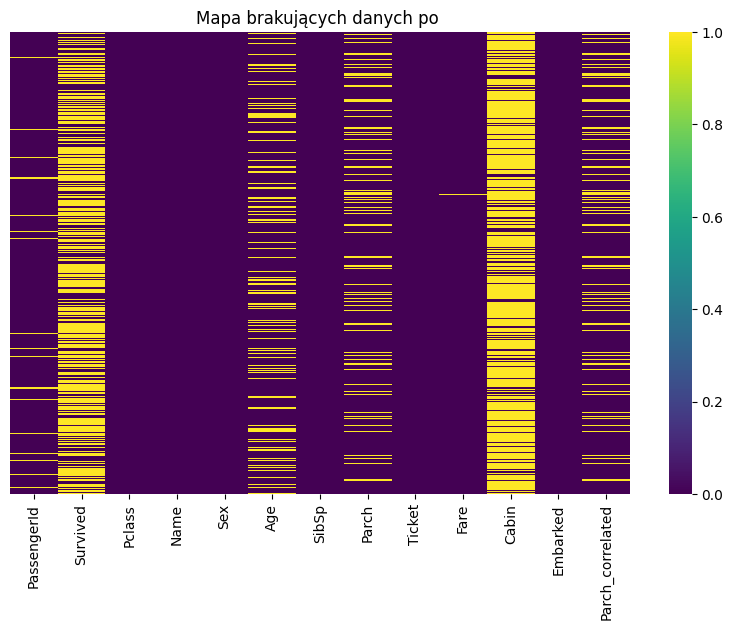

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df_zepsuty.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title("Mapa brakujących danych po ")
plt.show()

In [18]:
duplicate_count = df.duplicated().sum()
total_rows = len(df)

duplicate_percent = (duplicate_count / total_rows) * 100
original_percent = 100 - duplicate_percent


missing_df = pd.DataFrame({
    'Liczba_brakow': df_zepsuty.isnull().sum(),
    'Procent_brakow': (df_zepsuty.isnull().mean() * 100).round(2),
    'Liczba_duplikatów': df.duplicated().sum(),
    'Procent_duplikatów': duplicate_percent    
})

missing_df

,Liczba_brakow,Procent_brakow,Liczba_duplikatów,Procent_duplikatów
PassengerId,17,3.77,0,0.0
Survived,272,60.31,0,0.0
Pclass,0,0.00,0,0.0
Name,0,0.00,0,0.0
Sex,0,0.00,0,0.0
Age,94,20.84,0,0.0
SibSp,0,0.00,0,0.0
Parch,78,17.29,0,0.0
Ticket,0,0.00,0,0.0
Fare,1,0.22,0,0.0


# 2.1 handling missing values